In [ ]:
!pip install torch_geometric
!pip install pygsp

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 37.7 MB/s eta 0:00:00


In [ ]:
import networkx as nx
import numpy as np
import random

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

from sim_graphs import *

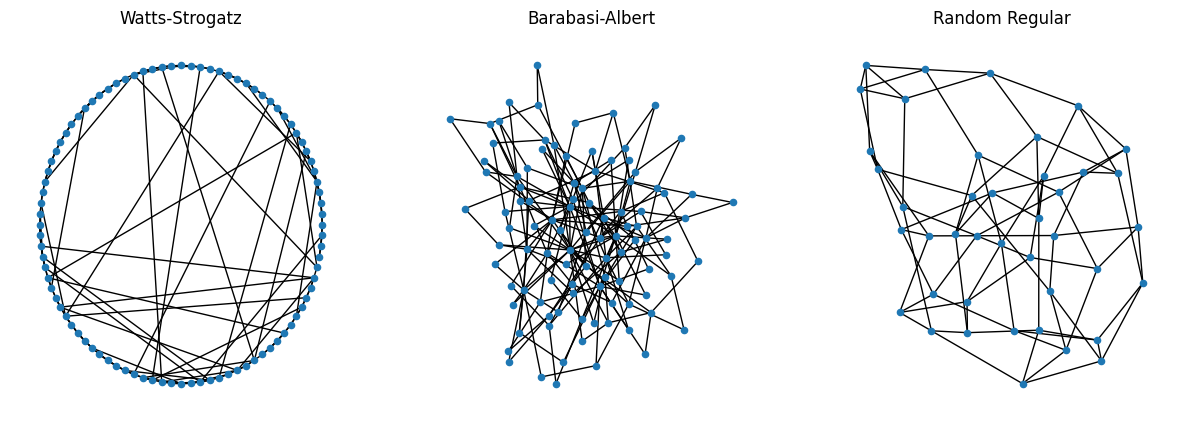

In [ ]:
# Example graph visualization

fig, axs = plt.subplots(1, 3, figsize=(15,5))

# Watts-Strogatz
G_ws = nx.watts_strogatz_graph(
    n=random.randint(20, 100),
    k=4,
    p=0.2
)

nx.draw(
    G_ws,
    pos=nx.circular_layout(G_ws),
    ax=axs[0],
    node_size=20
)

axs[0].set_title("Watts-Strogatz")


# Barabasi-Albert
G_ba = nx.barabasi_albert_graph(
    n=random.randint(20, 100),
    m=2
)

nx.draw(
    G_ba,
    pos=nx.spring_layout(G_ba),
    ax=axs[1],
    node_size=20
)

axs[1].set_title("Barabasi-Albert")


# Random Regular
G_rr = nx.random_regular_graph(
    d=4,
    n=random.randint(20, 100)
)

nx.draw(
    G_rr,
    pos=nx.spring_layout(G_rr),
    ax=axs[2],
    node_size=20
)

axs[2].set_title("Random Regular")

plt.show()

In [ ]:
# Graph-level feature extraction

def extract_features(G):

    degrees = [d for _, d in G.degree()]

    features = [

    np.mean(degrees),

    np.std(degrees)

]

    return features

In [ ]:
# Create dataset

X = []
y = []

# Watts-Strogatz graphs

for _ in range(500):
    n_nodes = random.randint(20, 100)
    G = generate_watts_strogatz(n_nodes)

    X.append(extract_features(G))

    y.append(0)


# Barabasi-Albert graphs

for _ in range(500):
    n_nodes = random.randint(20, 100)
    G = generate_barabasi_albert(n_nodes)

    X.append(extract_features(G))

    y.append(1)



# Random Regular graphs

for _ in range(500):
    n_nodes = random.randint(20, 100)
    G = generate_random_regular(n_nodes)

    X.append(extract_features(G))

    y.append(2)


# Convert to numpy arrays

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(1500, 2)
(1500,)


# training and test splits

In [ ]:


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)


# Create Random Forest model

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)


# train model
rf.fit(X_train, y_train)

# predictions
y_pred = rf.predict(X_test)

# accuracy
acc = accuracy_score(y_test, y_pred)
print("Random Forest Accuracy:", acc)

Random Forest Accuracy: 0.95


# plot

### confusion matrix

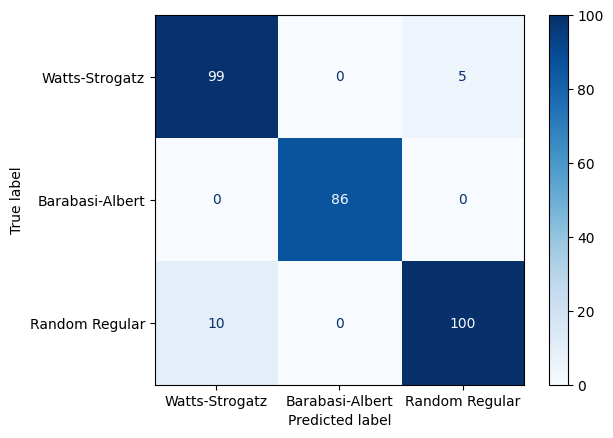

In [ ]:

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Watts-Strogatz",
        "Barabasi-Albert",
        "Random Regular"
    ]
)

disp.plot(cmap="Blues")

plt.show()